<a href="https://colab.research.google.com/github/f3r21/actas-cnn/blob/main/notebooks/02_modelo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# actas-cnn — Modelo + evaluacion (Colab)

CNN que reconoce las cifras manuscritas de conteo de votos en actas electorales (ONPE, Elecciones Generales del Peru 2026). Parte de los **crops preprocesados** (publicados por `01_preprocesamiento_colab.ipynb`) y va hasta las **metricas finales**.

**Prerequisito:** corre antes `01_preprocesamiento_colab.ipynb` una vez (publica `crops_bundle.tar.gz` en HF). Aqui el bundle se baja en segundos.

**Como correr:** Runtime -> Change runtime type -> **T4 GPU**, luego Runtime -> Run all.

| metrica (val, 693 actas) | esperado |
|---|---|
| digit-level | ~98.1% |
| field-level | ~98.9% |
| acta-level (42 campos) | ~90.3% |
| reconstruccion del total (MAE) | ~2.4 votos |

Un train fresco varia +-0.5pp por el seed; los resultados de cada corrida quedan en las salidas del notebook.

## 0. Setup

In [ ]:
# Dependencias (Colab ya trae torch, torchvision, numpy, pandas, matplotlib)
%pip install -q pymupdf==1.27.2.3 opencv-python-headless huggingface_hub pyarrow
print("deps instaladas")

deps instaladas


In [ ]:
# === Config + entorno ===
import os, tarfile
from pathlib import Path
import pandas as pd
import torch

def torch_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")
DEVICE = torch_device(); print("device:", DEVICE)
if DEVICE.type != "cuda":
    print("AVISO: sin GPU CUDA. En Colab: Runtime -> Change runtime type -> T4 GPU. "
          "Sin GPU el entrenamiento es MUY lento.")

HF_DATASET_REPO = "f3r21/actas-cnn-dataset"   # PDFs + labels (+ crops_bundle si 01 ya corrio)

WORK = Path("/content") if Path("/content").exists() else Path(".").resolve()
DATA = WORK / "data"; DATA.mkdir(parents=True, exist_ok=True)
# Epochs de entrenamiento (~5-8 min en T4 con 20).
EPOCHS = 20

device: cuda


In [ ]:
# Plantilla Presidencial: 42 campos (38 partidos + blanco/nulos/impugnados + total).
# Cajas en fraccion [0,1]; embebida para que el notebook sea autonomo.
TEMPLATE = { "descripcion": "ACTA DE ESCRUTINIO PRESIDENCIAL (idEleccion=10, tipo=1). iter7 auto-detected.", "image_size_reference": [ 2339, 3309 ], "fields": [ { "name": "partido_01", "box": [ 0.462, 0.2149, 0.539, 0.2315 ], "n_digits": 3 }, { "name": "partido_02", "box": [ 0.462, 0.2315, 0.539, 0.2481 ], "n_digits": 3 }, { "name": "partido_03", "box": [ 0.462, 0.2481, 0.539, 0.2648 ], "n_digits": 3 }, { "name": "partido_04", "box": [ 0.462, 0.2648, 0.539, 0.2814 ], "n_digits": 3 }, { "name": "partido_05", "box": [ 0.462, 0.2814, 0.539, 0.298 ], "n_digits": 3 }, { "name": "partido_06", "box": [ 0.462, 0.298, 0.539, 0.3146 ], "n_digits": 3 }, { "name": "partido_07", "box": [ 0.462, 0.3146, 0.539, 0.3312 ], "n_digits": 3 }, { "name": "partido_08", "box": [ 0.462, 0.3312, 0.539, 0.3479 ], "n_digits": 3 }, { "name": "partido_09", "box": [ 0.462, 0.3479, 0.539, 0.3645 ], "n_digits": 3 }, { "name": "partido_10", "box": [ 0.462, 0.3645, 0.539, 0.3811 ], "n_digits": 3 }, { "name": "partido_11", "box": [ 0.462, 0.3811, 0.539, 0.3977 ], "n_digits": 3 }, { "name": "partido_12", "box": [ 0.462, 0.3977, 0.539, 0.4143 ], "n_digits": 3 }, { "name": "partido_13", "box": [ 0.462, 0.4143, 0.539, 0.431 ], "n_digits": 3 }, { "name": "partido_14", "box": [ 0.462, 0.431, 0.539, 0.4476 ], "n_digits": 3 }, { "name": "partido_15", "box": [ 0.462, 0.4476, 0.539, 0.4642 ], "n_digits": 3 }, { "name": "partido_16", "box": [ 0.462, 0.4642, 0.539, 0.4808 ], "n_digits": 3 }, { "name": "partido_17", "box": [ 0.462, 0.4808, 0.539, 0.4974 ], "n_digits": 3 }, { "name": "partido_18", "box": [ 0.462, 0.4974, 0.539, 0.5141 ], "n_digits": 3 }, { "name": "partido_19", "box": [ 0.462, 0.5141, 0.539, 0.5307 ], "n_digits": 3 }, { "name": "partido_20", "box": [ 0.462, 0.5307, 0.539, 0.5473 ], "n_digits": 3 }, { "name": "partido_21", "box": [ 0.462, 0.5473, 0.539, 0.5639 ], "n_digits": 3 }, { "name": "partido_22", "box": [ 0.462, 0.5639, 0.539, 0.5805 ], "n_digits": 3 }, { "name": "partido_23", "box": [ 0.462, 0.5805, 0.539, 0.5972 ], "n_digits": 3 }, { "name": "partido_24", "box": [ 0.462, 0.5972, 0.539, 0.6138 ], "n_digits": 3 }, { "name": "partido_25", "box": [ 0.462, 0.6138, 0.539, 0.6304 ], "n_digits": 3 }, { "name": "partido_26", "box": [ 0.462, 0.6304, 0.539, 0.647 ], "n_digits": 3 }, { "name": "partido_27", "box": [ 0.462, 0.647, 0.539, 0.6636 ], "n_digits": 3 }, { "name": "partido_28", "box": [ 0.462, 0.6636, 0.539, 0.6803 ], "n_digits": 3 }, { "name": "partido_29", "box": [ 0.462, 0.6803, 0.539, 0.6969 ], "n_digits": 3 }, { "name": "partido_30", "box": [ 0.462, 0.6969, 0.539, 0.7135 ], "n_digits": 3 }, { "name": "partido_31", "box": [ 0.462, 0.7135, 0.539, 0.7301 ], "n_digits": 3 }, { "name": "partido_32", "box": [ 0.462, 0.7301, 0.539, 0.7467 ], "n_digits": 3 }, { "name": "partido_33", "box": [ 0.462, 0.7467, 0.539, 0.7634 ], "n_digits": 3 }, { "name": "partido_34", "box": [ 0.462, 0.7634, 0.539, 0.78 ], "n_digits": 3 }, { "name": "partido_35", "box": [ 0.462, 0.78, 0.539, 0.7966 ], "n_digits": 3 }, { "name": "partido_36", "box": [ 0.462, 0.7966, 0.539, 0.8132 ], "n_digits": 3 }, { "name": "partido_37", "box": [ 0.462, 0.8132, 0.539, 0.8298 ], "n_digits": 3 }, { "name": "partido_38", "box": [ 0.462, 0.8298, 0.539, 0.8465 ], "n_digits": 3 }, { "name": "votos_blanco", "box": [ 0.462, 0.8465, 0.539, 0.8631 ], "n_digits": 3 }, { "name": "votos_nulos", "box": [ 0.462, 0.8631, 0.539, 0.8797 ], "n_digits": 3 }, { "name": "votos_impugnados", "box": [ 0.462, 0.8797, 0.539, 0.8963 ], "n_digits": 3 }, { "name": "total_ciudadanos", "box": [ 0.4363, 0.8963, 0.539, 0.913 ], "n_digits": 4 } ] }

## 1. Codigo del modelo (inline)

Modelo, dataset, entrenamiento y evaluacion. El preprocesamiento (deteccion de digitos) vive en `01_preprocesamiento_colab.ipynb`.

In [ ]:
# === Modelo del proyecto: ResNet-18 estilo CIFAR (He et al., 2015) ===
import torch.nn as nn
from torchvision.models import resnet18 as _torchvision_resnet18

def resnet18_cifar(in_channels=1, num_classes=10):
    """ResNet-18 adaptada a entradas 1x32x32: stem 3x3 stride 1, sin MaxPool
    inicial (preserva resolucion), 1 canal. Mantiene las 4 etapas residuales,
    GAP (1,1) y Linear(512, num_classes). 11.17M params."""
    m = _torchvision_resnet18(num_classes=num_classes)
    m.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

In [ ]:
# === Dataset de crops + transforms ===
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

def default_transforms(image_size=32, train=True, randaugment=False):
    ops = [transforms.Grayscale(num_output_channels=1),
           transforms.Resize((image_size, image_size))]
    if train:
        ops.append(transforms.RandomAffine(degrees=8, translate=(0.1, 0.1), scale=(0.9, 1.1)))
        if randaugment:
            ops.append(transforms.RandAugment(num_ops=2, magnitude=9))
    ops += [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    return transforms.Compose(ops)

class CropsDataset(Dataset):
    def __init__(self, manifest_csv, root=".", transform=None):
        self.df = pd.read_csv(manifest_csv)
        self.root = Path(root)
        self.transform = transform or default_transforms()
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = self.transform(Image.open(self.root / row["path"]))
        return x, torch.tensor(int(row["label"]), dtype=torch.long)

In [ ]:
# === Entrenamiento (ResNet-18, recipe base, ~5-8 min en T4) ===
import os
import numpy as np
from torch.utils.data import DataLoader, random_split

def _mixup(x, y, alpha):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def run_epoch(model, loader, device, criterion, optimizer=None, mixup_alpha=0.0):
    is_train = optimizer is not None
    model.train(is_train)
    total = correct = 0; loss_sum = 0.0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train and mixup_alpha > 0:
                xm, ya, yb, lam = _mixup(x, y, mixup_alpha)
                out = model(xm)
                loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
                correct += (out.argmax(1) == ya).sum().item()
            else:
                out = model(x); loss = criterion(out, y)
                correct += (out.argmax(1) == y).sum().item()
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0); total += x.size(0)
    return loss_sum / total, correct / total

def train_model(manifest, root, device, epochs=20, lr=5e-4, batch_size=128,
                label_smoothing=0.0, randaugment=False, mixup=0.0, cosine_lr=False,
                seed=42):
    # Defaults = recipe BASE (sin RandAugment): rapido y consistente con el
    # checkpoint oficial resnet18_best.pt (~90.3% acta). RandAugment corre en CPU
    # por imagen y es el cuello de botella en Colab; activalo (randaugment=True,
    # mixup=0.2, cosine_lr=True, label_smoothing=0.1) solo para la ablacion ls_ra_mu_cos.
    torch.manual_seed(seed)
    full = CropsDataset(manifest, root=root,
                        transform=default_transforms(32, train=True, randaugment=randaugment))
    n_val = max(1, int(0.2 * len(full)))
    tr, va = random_split(full, [len(full) - n_val, n_val])
    pin = device.type == "cuda"
    nw = min(4, os.cpu_count() or 2)
    trl = DataLoader(tr, batch_size=batch_size, shuffle=True, num_workers=nw,
                     pin_memory=pin, persistent_workers=nw > 0)
    val = DataLoader(va, batch_size=batch_size, shuffle=False, num_workers=nw,
                     pin_memory=pin, persistent_workers=nw > 0)
    model = resnet18_cifar(1, 10).to(device)
    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine_lr else None
    best = 0.0
    for ep in range(1, epochs + 1):
        _, tra = run_epoch(model, trl, device, crit, opt, mixup_alpha=mixup)
        _, vaa = run_epoch(model, val, device, crit)
        if sched: sched.step()
        best = max(best, vaa)
        print(f"epoch {ep:02d}  train_acc {tra:.4f}  val_acc {vaa:.4f}")
    print(f"mejor val_acc (holdout interno): {best:.4f}")
    return model

In [ ]:
# === Evaluacion downstream: digit / field / acta-level + reconstruccion del total ===
import numpy as np

def field_value_for(name, votos_acta, total_emitidos):
    """Entero del ground truth para un campo (partido / blanco-nulos-impugnados / total)."""
    if name.startswith("partido_"):
        pos = int(name.split("_")[1])
        row = votos_acta[votos_acta["nposicion"] == pos]
        return int(row.iloc[0]["nvotos"]) if len(row) else 0
    mapping = {"votos_blanco": 80, "votos_nulos": 81, "votos_impugnados": 82}
    if name in mapping:
        row = votos_acta[votos_acta["nposicion"] == mapping[name]]
        return int(row.iloc[0]["nvotos"]) if len(row) else 0
    if name == "total_ciudadanos":
        return int(total_emitidos)
    raise ValueError(name)

def parse_crop_path(rel):
    """'<label>/<aid>_<field>_c<pos>.png' -> (aid, field, pos)."""
    parts = Path(rel).stem.split("_")
    return parts[0], "_".join(parts[1:-1]), int(parts[-1][1:])

def reconstruct_value(preds_by_pos, n_cells):
    """Digitos predichos -> entero right-justified (posiciones faltantes = 0)."""
    return int("".join(str(preds_by_pos.get(p, 0)) for p in range(n_cells)))

@torch.no_grad()
def evaluate_split(model, manifest, crops_root, template, archivos, votos, cabecera, device):
    """Devuelve (df_celdas, res_campos): digit-level en df, field/acta-level en res."""
    model.eval()
    field_specs = {f["name"]: f["n_digits"] for f in template["fields"]}
    aid_to_idacta = dict(zip(archivos["archivoId"], archivos["idActa"]))
    ds = CropsDataset(manifest, root=crops_root, transform=default_transforms(32, train=False))
    df = ds.df.reset_index(drop=True)
    preds = []
    loader = DataLoader(ds, batch_size=512, shuffle=False,
                        num_workers=min(4, os.cpu_count() or 2))
    for x, _ in loader:
        preds.append(model(x.to(device)).argmax(1).cpu().numpy())
    df["pred"] = np.concatenate(preds)
    parsed = df["path"].apply(parse_crop_path).apply(pd.Series)
    parsed.columns = ["archivoId", "field", "pos"]
    df = pd.concat([df, parsed], axis=1)
    rows = []
    for aid, da in df.groupby("archivoId"):
        if aid not in aid_to_idacta:
            continue
        ida = int(aid_to_idacta[aid])
        cab = cabecera[cabecera["idActa"] == ida]
        if len(cab) == 0 or pd.isna(cab.iloc[0]["totalVotosEmitidos"]):
            continue
        total = int(cab.iloc[0]["totalVotosEmitidos"])
        va = votos[votos["idActa"] == ida]
        for fname, n_cells in field_specs.items():
            cf = da[da["field"] == fname]
            pv = reconstruct_value(dict(zip(cf["pos"], cf["pred"])), n_cells)
            rv = field_value_for(fname, va, total)
            rows.append({"archivoId": aid, "field": fname, "pred": pv, "real": rv,
                         "correct": pv == rv, "error": pv - rv})
    res = pd.DataFrame(rows)
    n_eval, n_total = res["archivoId"].nunique(), df["archivoId"].nunique()
    if n_eval < n_total:
        print(f"aviso: {n_eval}/{n_total} actas evaluadas "
              f"({n_total - n_eval} sin ground truth en los parquets)")
    return df, res

def report_metrics(df, res):
    """Imprime y devuelve el dict de metricas oficiales."""
    digit = float(df["pred"].eq(df["label"]).mean())
    field = float(res["correct"].mean())
    acta = float(res.groupby("archivoId")["correct"].all().mean())
    no_tot = res[res["field"] != "total_ciudadanos"]
    err = (no_tot.groupby("archivoId")["pred"].sum() - no_tot.groupby("archivoId")["real"].sum())
    mae = float(err.abs().mean()); exact = float((err == 0).mean() * 100)
    print(f"digit-level : {digit:.4f}  (n={len(df)})")
    print(f"field-level : {field:.4f}")
    print(f"acta-level  : {acta:.4f}")
    print(f"reconstruccion total: MAE {mae:.2f} votos, exacta {exact:.2f}% de actas")
    return {"digit": digit, "field": field, "acta": acta, "total_mae": mae,
            "total_exact_pct": exact}

In [ ]:
# === Metricas para el informe: matriz de confusion, P/R/F1 por clase, ablations ===
import numpy as np
import matplotlib.pyplot as plt

def confusion_and_prf(df):
    """Matriz 10x10 + tabla precision/recall/F1 por clase (digit-level)."""
    cm = np.zeros((10, 10), dtype=np.int64)
    for t, p in zip(df["label"].values, df["pred"].values):
        cm[int(t), int(p)] += 1
    recall = np.array([cm[i, i] / max(cm[i].sum(), 1) for i in range(10)])
    prec = np.array([cm[i, i] / max(cm[:, i].sum(), 1) for i in range(10)])
    f1 = np.array([2 * p * r / max(p + r, 1e-9) for p, r in zip(prec, recall)])
    prf = pd.DataFrame({"clase": range(10), "n": cm.sum(1),
                        "precision": prec, "recall": recall, "f1": f1})
    return cm, prf

def plot_confusion(cm, acc):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusion (acc={acc:.4f})")
    vmax = cm.max()
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > vmax / 2 else "black")
    fig.colorbar(im); fig.tight_layout(); plt.show()

def ablations_table(csv_map):
    """{nombre: ruta_evaluate_val_*.csv} -> tabla field/acta-level + MAE del total."""
    rows = []
    for nombre, csv_path in csv_map.items():
        r = pd.read_csv(csv_path)
        no_tot = r[r["field"] != "total_ciudadanos"]
        err = (no_tot.groupby("archivoId")["pred"].sum()
               - no_tot.groupby("archivoId")["real"].sum()).abs()
        rows.append({"variante": nombre,
                     "field_acc": r["correct"].mean(),
                     "acta_acc": r.groupby("archivoId")["correct"].all().mean(),
                     "total_mae": err.mean()})
    return pd.DataFrame(rows).set_index("variante")

## 2. Datos: crops preprocesados (cache de HF)

In [ ]:
from huggingface_hub import hf_hub_download, snapshot_download

snapshot_download(HF_DATASET_REPO, repo_type="dataset", allow_patterns="labels/*",
                  local_dir=str(DATA))
archivos = pd.read_parquet(DATA / "labels/actas_archivos.parquet")
votos    = pd.read_parquet(DATA / "labels/actas_votos.parquet")
cabecera = pd.read_parquet(DATA / "labels/actas_cabecera.parquet")

# Crops preprocesados publicados por 01_preprocesamiento_colab.ipynb.
try:
    bundle = hf_hub_download(HF_DATASET_REPO, "crops_bundle.tar.gz", repo_type="dataset")
except Exception as e:
    raise RuntimeError("No hay crops_bundle.tar.gz en HF. Corre "
                       "01_preprocesamiento_colab.ipynb primero.") from e
with tarfile.open(bundle) as t: t.extractall(WORK)
print("crops_bundle extraido")

Fetching ... files: 0it [00:00, ?it/s]

/tmp/ipykernel_17329/2314762994.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(bundle) as t: t.extractall(WORK)


crops_bundle extraido


## 3. Entrenamiento

In [ ]:
model = train_model(DATA / "manifest_train.csv", DATA / "crops_train", DEVICE, epochs=EPOCHS)

epoch 01  train_acc 0.9153  val_acc 0.9420
epoch 02  train_acc 0.9681  val_acc 0.9689
epoch 03  train_acc 0.9715  val_acc 0.9709
epoch 04  train_acc 0.9730  val_acc 0.9717
epoch 05  train_acc 0.9734  val_acc 0.9716
epoch 06  train_acc 0.9747  val_acc 0.9704
epoch 07  train_acc 0.9746  val_acc 0.9741
epoch 08  train_acc 0.9758  val_acc 0.9737
epoch 09  train_acc 0.9759  val_acc 0.9712
epoch 10  train_acc 0.9764  val_acc 0.9744
epoch 11  train_acc 0.9770  val_acc 0.9745
epoch 12  train_acc 0.9772  val_acc 0.9722
epoch 13  train_acc 0.9773  val_acc 0.9750
epoch 14  train_acc 0.9779  val_acc 0.9752
epoch 15  train_acc 0.9781  val_acc 0.9735
epoch 16  train_acc 0.9785  val_acc 0.9762
epoch 17  train_acc 0.9786  val_acc 0.9736
epoch 18  train_acc 0.9788  val_acc 0.9751
epoch 19  train_acc 0.9794  val_acc 0.9768
epoch 20  train_acc 0.9794  val_acc 0.9762
mejor val_acc (holdout interno): 0.9768


## 4. Evaluacion + metricas finales

In [ ]:
df, res = evaluate_split(model, DATA / "manifest_val.csv", DATA / "crops_val",
                         TEMPLATE, archivos, votos, cabecera, DEVICE)
metrics = report_metrics(df, res)

digit-level : 0.9760  (n=22876)
field-level : 0.9855
acta-level  : 0.8759
reconstruccion total: MAE 2.58 votos, exacta 91.05% de actas


## 5. Visualizaciones + tabla de ablations

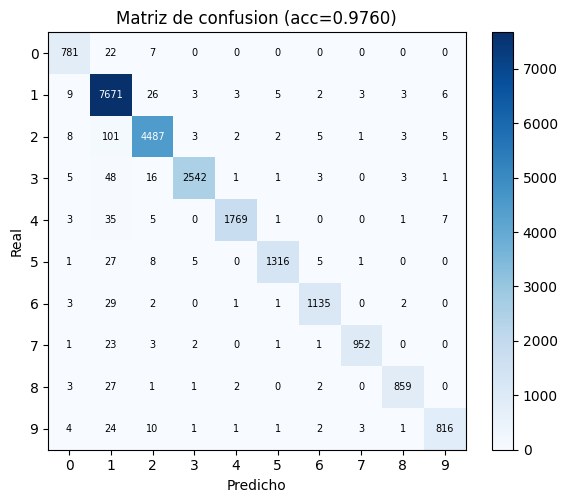


precision / recall / F1 por clase:
 clase    n  precision  recall     f1
     0  810     0.9548  0.9642 0.9595
     1 7731     0.9580  0.9922 0.9748
     2 4617     0.9829  0.9718 0.9773
     3 2620     0.9941  0.9702 0.9820
     4 1821     0.9944  0.9714 0.9828
     5 1363     0.9910  0.9655 0.9781
     6 1173     0.9827  0.9676 0.9751
     7  983     0.9917  0.9685 0.9799
     8  895     0.9851  0.9598 0.9723
     9  863     0.9772  0.9455 0.9611

(ablations: corre scripts/evaluate.py por variante en local para la tabla del informe)


In [ ]:
cm, prf = confusion_and_prf(df)
plot_confusion(cm, metrics["digit"])
print("\nprecision / recall / F1 por clase:")
print(prf.round(4).to_string(index=False))

# Tabla de ablations (si estan los CSV de evaluate por variante en data/).
csv_map = {n: DATA / f for n, f in [("base", "evaluate_val.csv"),
           ("ls_ra", "evaluate_val_ls_ra.csv"),
           ("ls_ra_mu_cos", "evaluate_val_ls_ra_mu_cos.csv")] if (DATA / f).exists()}
if csv_map:
    print("\nablations:"); print(ablations_table(csv_map).round(4))
else:
    print("\n(ablations: corre scripts/evaluate.py por variante en local para la tabla del informe)")

---
**Cierre.** Pipeline completo desde el PDF del acta hasta las metricas de reconstruccion de votos. Modelo: ResNet-18 estilo CIFAR. El detalle metodologico y los experimentos (preprocesamiento alternativo, solver) viven en el repo (`docs/`, `experiments/`).